# Last couple of plots for thesis

In [1]:
from fbm import FBM
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns
from scipy import stats, signal
from scipy.stats import linregress

from fbm import FBM

# Add .. to the path
import sys

sys.path.append("..")
import src.sf_funcs as sf_funcs

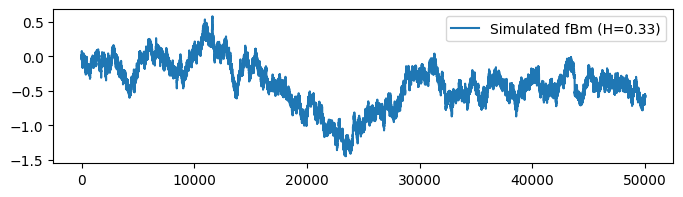

In [2]:
# Simulate fractional Brownian motion
np.random.seed(43)

n = 100000  # Number of points
quicklook_n = 50000  # Number of points to plot for quicklook


hurst = 1 / 3  # Hurst parameter (0 < H < 1) = alpha/p for SF scaling
fbm_sim = FBM(n=n, hurst=hurst, length=1)
ts_sim = fbm_sim.fbm()[:n]

plt.figure(figsize=(8, 2))
plt.plot(ts_sim[:quicklook_n], label=f"Simulated fBm (H={hurst:.2f})")
plt.legend()

In [4]:
# Read in cleaned Voyager 1 data
df = pd.read_pickle("../data/interim/voyager/voyager1_lism.pkl")
print("Loaded dataset")

Loaded dataset


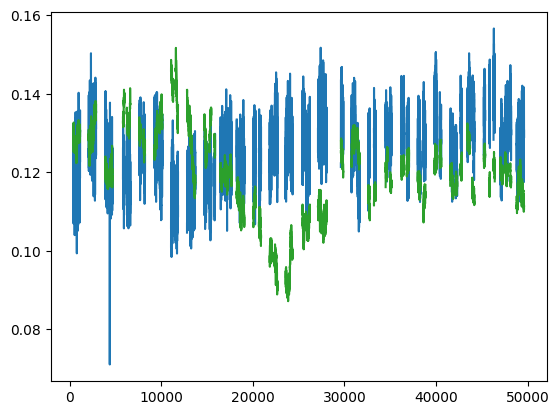

In [5]:

# Set simulated data to NaN where Voyager 1 data is missing
v1_subset = df.BR[:n]
v1_missing_mask = v1_subset.isna()

ts_sim_v1_gaps = ts_sim.copy()
ts_sim_v1_gaps[v1_missing_mask] = (
    np.nan
)

# Normalize the simulated data to match the mean and standard deviation of the Voyager 1 data
ts_sim_v1_gaps_std = ts_sim_v1_gaps / np.nanstd(ts_sim_v1_gaps) * np.nanstd(
    v1_subset
) + np.nanmean(v1_subset)

plt.plot(v1_subset.values[:quicklook_n], label="Voyager 1 LISM", color="C0")
plt.plot(ts_sim_v1_gaps_std[:quicklook_n], label="Simulated fBm", color="C2")

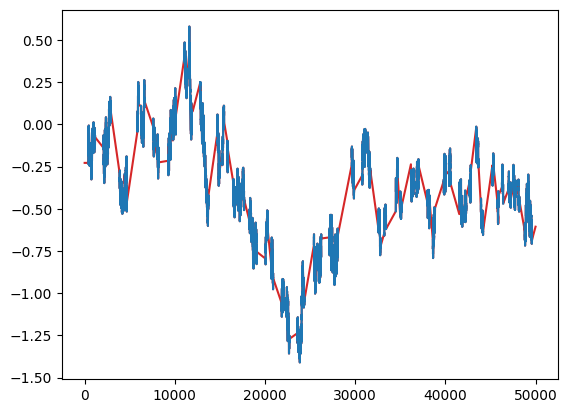

In [6]:
ts_sim_v1_gaps_lint = pd.DataFrame(
    ts_sim_v1_gaps, index=df.index[:n], columns=["Simulated fBm"])

ts_sim_v1_gaps_lint = ts_sim_v1_gaps_lint.interpolate(
    method="linear", limit_direction="both", axis=0)

plt.plot(ts_sim_v1_gaps_lint.values[:quicklook_n], label="Interpolated fBm", color="C3")
plt.plot(ts_sim_v1_gaps[:quicklook_n])

In [7]:
v1_subset_lint = v1_subset.interpolate(
    method="linear", limit_direction="both", axis=0)

In [8]:
# # Get SF func and compare these two against full ts_sim


# sf_sim_v1_gaps = sf_funcs.compute_sf(
#     pd.DataFrame(ts_sim_v1_gaps), lags, [2], False, False, None
# ).sf_2

# sf_sim_v1_lint = sf_funcs.compute_sf(
#     pd.DataFrame(ts_sim_v1_gaps_lint.values),
#     lags,
#     [2],
#     False,
#     False,
#     None,
# ).sf_2

# sf_v1 = sf_funcs.compute_sf(
#     pd.DataFrame(v1_subset), lags, [2], False, False, None
# ).sf_2

# sf_v1_lint = sf_funcs.compute_sf(
#     pd.DataFrame(v1_subset_lint), lags, [2], False, False, None
# ).sf_2

# sf_sim = sf_funcs.compute_sf(
#     pd.DataFrame(ts_sim), lags, [2], False, False, None
# ).sf_2

In [9]:
max_lag = n/2
nlags=1000
lags = np.logspace(0, np.log10(max_lag), nlags)
# Convert array to integers
lags = [int(x) for x in lags]
# Drop duplicate lags
lags = np.unique([int(x) for x in lags])

In [10]:
sf_sim_v1_gaps = sf_funcs.compute_sf_fast(
    pd.DataFrame(ts_sim_v1_gaps), lags, [2], False
)

sf_sim_v1_lint = sf_funcs.compute_sf_fast(
    pd.DataFrame(ts_sim_v1_gaps_lint.values),
    lags,
    [2],
    False,
)

sf_v1 = sf_funcs.compute_sf_fast(
    pd.DataFrame(v1_subset), lags, [2], False
)

sf_v1_lint = sf_funcs.compute_sf_fast(
    pd.DataFrame(v1_subset_lint), lags, [2], False
)


sf_sim = sf_funcs.compute_sf_fast(
    pd.DataFrame(ts_sim), lags, [2], False,)

In [11]:
pd.isna(ts_sim_v1_gaps_lint).sum()

Simulated fBm    0
dtype: int64

Text(0.5, 1.0, 'N = 100,000, 71% removed according to V1 gap locations')

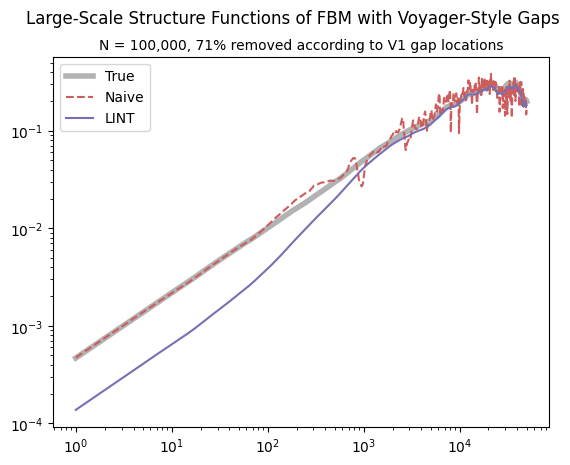

In [12]:
plt.loglog(lags, sf_sim, label="True", color="black", lw=4, alpha=0.3)
plt.loglog(
    lags,
    sf_sim_v1_gaps,
    label="Naive",
    color="indianred",
    linestyle="--",
)
plt.loglog(
    lags,
    sf_sim_v1_lint,
    label="LINT",
    color="#7570b3",
)
plt.legend()
plt.suptitle("Large-Scale Structure Functions of FBM with Voyager-Style Gaps")
plt.title("N = 100,000, 71% removed according to V1 gap locations", fontsize=10)

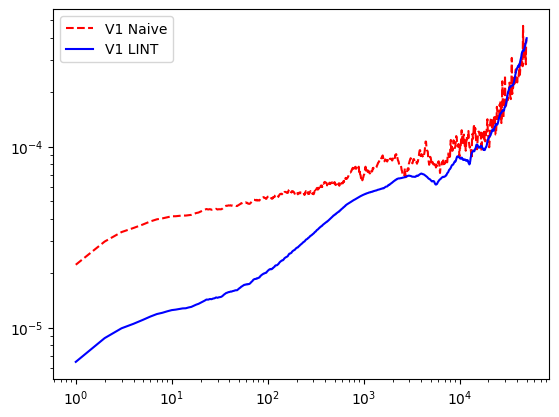

In [13]:
plt.loglog(lags, sf_v1, label="V1 Naive", color="red", linestyle="--")
plt.loglog(lags, sf_v1_lint, label="V1 LINT", color="blue")
plt.legend()

## Run loop for multiple gap types
Just need to get gapping fn from latest pipeline

In [14]:
# Gap ts_sim in other ways, using our standard function
# Gap between 60%, 70%, 80%, combinations of contiguous and uniform, and V1 gap mask.

results_df = pd.DataFrame(columns=["gap_fraction", "ts_gapped", "sf", "gap_handling"])
minimum_missing_chunks = 0.7

import src.ts_dashboard_utils as ts

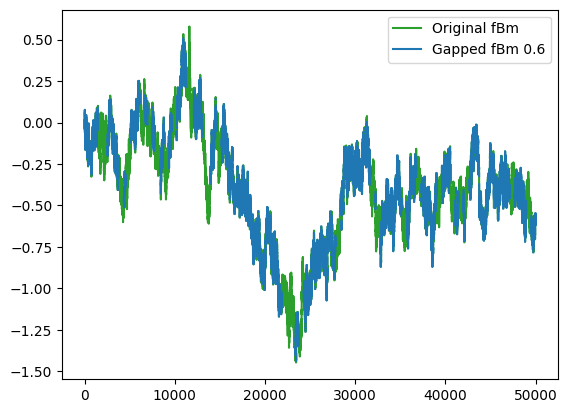

C:\Users\spann\AppData\Local\Temp\ipykernel_28060\958402718.py:53: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results_df = pd.concat([results_df, new_row], ignore_index=True)


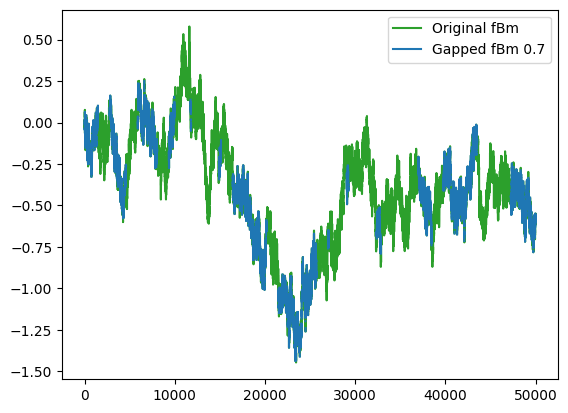

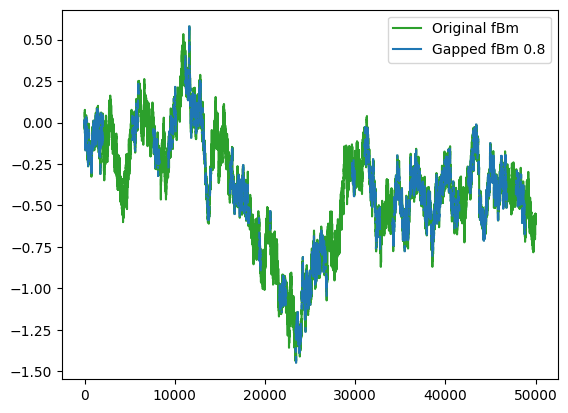

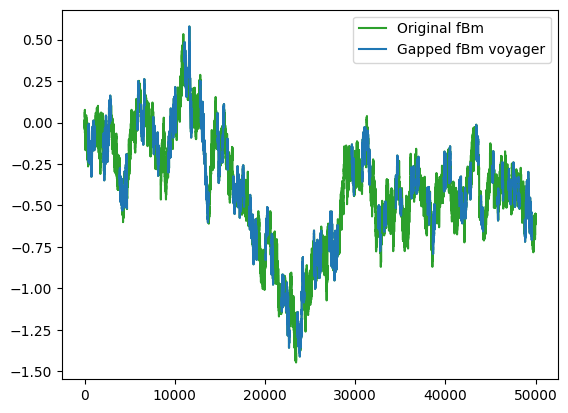

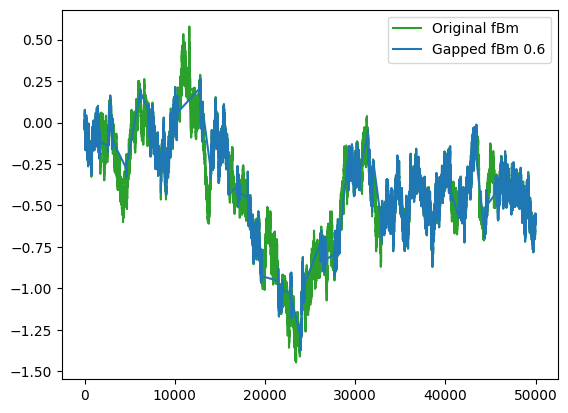

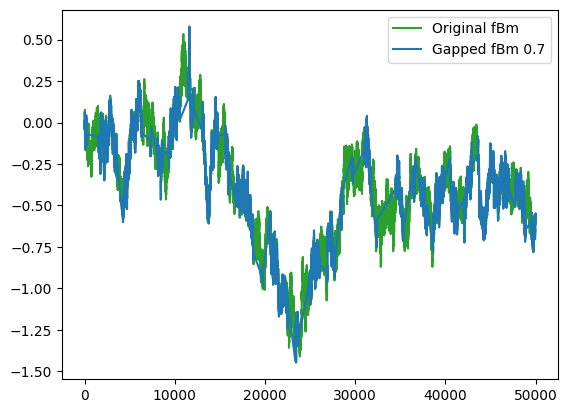

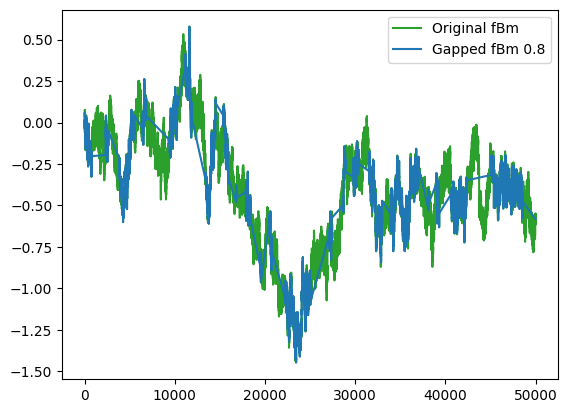

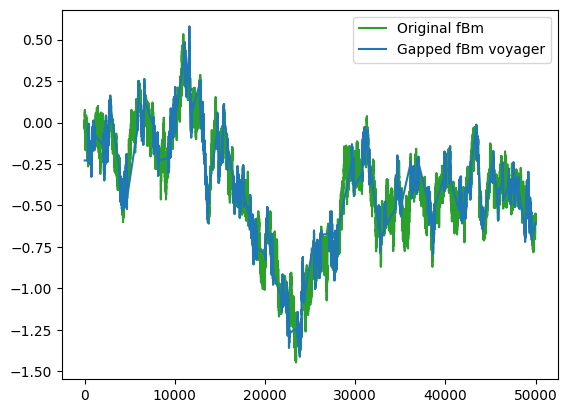

In [15]:
for gap_handling in ["naive", "lint"]:
    for gap_fraction in [0.6, 0.7, 0.8, "voyager"]:

        ts_sim_gapped = ts_sim.copy()

        if gap_fraction == "voyager":
            # Use the Voyager 1 missing mask
            gap_mask = v1_missing_mask.values
            ts_sim_gapped[v1_missing_mask] = np.nan
            ts_sim_gapped = pd.DataFrame(ts_sim_gapped)

        else:
            # Create a random gap mask based on the specified fraction
            total_removal = gap_fraction
            ratio_removal = np.random.uniform(minimum_missing_chunks, 1)
            # print("Nominal total removal: {0:.1f}%".format(total_removal * 100))
            # print("Nominal ratio: {0:.1f}%".format(ratio_removal * 100))
            prop_remove_chunks = total_removal * ratio_removal

            bad_input_chunks, bad_input_ind_chunks, prop_removed_chunks = ts.remove_data(
                pd.DataFrame(ts_sim_gapped), prop_remove_chunks, chunks=np.random.randint(50, 100)
            )
            # Now calculate amount to remove uniformly, given that
            # amount removed in chunks will invariably differ from specified amount
            prop_remove_unif = total_removal - prop_removed_chunks

            # Add the uniform gaps on top of chunks gaps
            ts_sim_gapped, bad_input_ind, prop_removed = ts.remove_data(
                bad_input_chunks, prop_remove_unif
            )
        if gap_handling == "lint":
            # Interpolate the gaps linearly
            ts_sim_gapped = (
            ts_sim_gapped
                .interpolate(method="linear", limit_direction="both")
                .values
            )

        plt.plot(ts_sim[:quicklook_n], label="Original fBm", color="C2")
        plt.plot(ts_sim_gapped[:quicklook_n], label=f"Gapped fBm {gap_fraction}")
        plt.legend()
        plt.show()

        sf = sf_funcs.compute_sf_fast(pd.DataFrame(ts_sim_gapped), lags, [2], False)

        # Use pd.concat instead of append (append is deprecated)
        new_row = pd.DataFrame([{
            "gap_fraction": gap_fraction,
            "ts_gapped": ts_sim_gapped,
            "sf": sf,
            "gap_handling": gap_handling,
        }])
        results_df = pd.concat([results_df, new_row], ignore_index=True)

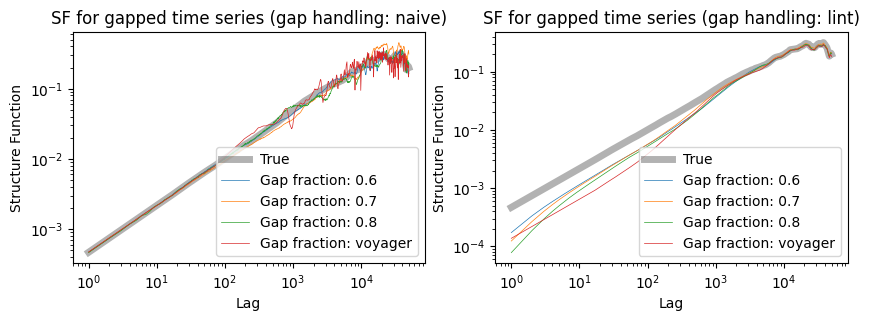

In [16]:
naive_results = results_df[results_df.gap_handling == "naive"]

fig, ax = plt.subplots(1,2, figsize=(10, 3))
ax[0].loglog(lags, sf_sim, label="True", color="black", lw=5, alpha=0.3)
for row in naive_results.itertuples():
    ax[0].loglog(lags, row.sf, label=f"Gap fraction: {row.gap_fraction}", lw=0.5)
    ax[0].set_title(f"SF for gapped time series (gap handling: {row.gap_handling})")
    ax[0].set_xlabel("Lag")
    ax[0].set_ylabel("Structure Function")
    ax[0].legend()

lint_results = results_df[results_df.gap_handling == "lint"]

ax[1].loglog(lags, sf_sim, label="True", color="black", lw=5, alpha=0.3)
for row in lint_results.itertuples():
    ax[1].loglog(lags, row.sf, label=f"Gap fraction: {row.gap_fraction}", lw=0.5)
    ax[1].set_title(f"SF for gapped time series (gap handling: {row.gap_handling})")
    ax[1].set_xlabel("Lag")
    ax[1].set_ylabel("Structure Function")
    ax[1].legend()
plt.show()